# v4 - Poisson-B vs Fix_W, 80 days, bottom and plume, +W and -W

Two corrections compared on identical seeds:

| tag | U, V | W |
|---|---|---|
| `poisson_b` | rescaled + barotropic Poisson correction | rebuilt from the corrected U,V (linear weighting) |
| `fix_w` | raw GLORYS | `vovecrtz` minus the surface kinematic BC taper, `W(0)=0` exactly |

`Fix_W` only produces W, so that experiment keeps GLORYS' own U and V. Each is run with `+W`
(as stored) and `-W`, from two release regions, for 80 days: 1993-01-02 to 1993-03-23, spanning
all three monthly files.

## No vertical boundary condition is imposed

Passive particles have no inertia and nothing to bounce off, so no reflection, clamping or
error-suppression is applied. None is needed: the kinematic condition `w = 0` on an impermeable
boundary is already satisfied *exactly* by the data, at the free surface (`k = 0`) and at the
bottom face of the deepest wet cell (`k = mbathy`), in all 425,361 wet columns. A particle
approaching a face where `w -> 0` decelerates and cannot cross it. Any crossing that does occur
is therefore numerical (RK4 truncation), and is *measured* here rather than patched.

**The floor is `gdepw_0[mbathy]`, not the true seabed.** The zero-`w` value is stored at index
`k = mbathy`, and Parcels labels that index with depth `gdepw_0[mbathy]`. The physical seabed
`H = gdepw_0[mbathy-1] + e3t_ps` (the bottom of the partial cell) lies *above* it - by 118 m on
average, 2.5 m on the shelf, and more than 1 m in 81% of wet columns. Between `H` and
`gdepw_0[mbathy]` the interpolated `w` is nonzero, so the field's own no-flux face is the deeper
one. Treating `H` as a wall puts a barrier inside water the field considers open, which is what
produced the boundary crossings in v3. Both depths are recorded below so the difference is visible.


In [1]:
n_per_region       = 200
run_time_days      = 80
time_step_minutes  = 20
out_put_step_hours = 6

ref_date, offset = "1993-01-01", 1
rdm_seed = 110987
MONTHS = [1, 2, 3]

Hgr, Zgr = "Hgr_cmesh.nc", "Zgr_cmesh2.nc"

def mf(pat):
    return [pat.format(y=1993, m=m) for m in MONTHS]

FIELDSETS = {
    "poisson_b": dict(U=mf("U_{y}-{m:02d}b.nc"), V=mf("V_{y}-{m:02d}b.nc"),
                      W=mf("W_{y}-{m:02d}b.nc")),
    "fix_w":     dict(U=mf("U_{y}-{m:02d}.nc"),  V=mf("V_{y}-{m:02d}.nc"),
                      W=mf("W_{y}-{m:02d}fc2.nc")),
}

SHELF_H   = (20.0, 100.0)
SHELF_BOX = dict(lon=(-52, -46), lat=(-1.5, 4.5))
PLUME_LINE = dict(lon=(-49.916, -49.083), lat=(1.166, -0.0833), z=(0.0, 10.0))

out_root    = "tracks_v4"
FORCE_RERUN = False

In [2]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from parcels import (FieldSet, Field, ParticleSet, JITParticle, Variable,
                     AdvectionRK4_3D, StatusCode)

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

for tag, f in FIELDSETS.items():
    missing = [p for v in ("U", "V", "W") for p in f[v] if not os.path.exists(p)]
    print(f"{tag:<10} {'OK' if not missing else 'MISSING: ' + ', '.join(missing)}")

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
nout = int(run_time_days * 24 / out_put_step_hours) + 1
print(f"\n{start_time} -> {start_time + np.timedelta64(run_time_days,'D')}"
      f"   dt={time_step_minutes} min   {nout} outputs")

poisson_b  OK
fix_w      OK

1993-01-02 -> 1993-03-23   dt=20 min   321 outputs


## 1. Grid, true seabed, seeds

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
hgr = xr.open_dataset(Hgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values.astype("f8"), zgr.nav_lat.values.astype("f8")
glamf, gphif = hgr.glamf.values.astype("f8"), hgr.gphif.values.astype("f8")
nz, ny, nx = len(gdepw_0), *mbathy.shape

kb    = np.clip(mbathy - 1, 0, nz - 1)
thick = np.where(mbathy > 0, e3t_ps, 0.0)
H     = gdepw_0[kb] + thick            # true seabed (bottom of the partial cell)
Gnom  = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, nz - 1)], 0.0)
#       ^ the depth Parcels assigns to the zero-w face at k=mbathy: the field's own floor
zbot  = gdepw_0[kb] + 0.5 * thick      # middle of the deepest wet cell

wj, wi = np.where(mbathy > 0)
tree   = cKDTree(np.column_stack([lon2d[wj, wi], lat2d[wj, wi]]))
Hw     = H[wj, wi]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)]); ok = np.isfinite(f).all(1)
    o = np.full(len(f), np.nan)
    if ok.any(): o[ok] = Hw[tree.query(f[ok])[1]]
    return o.reshape(np.shape(lo))

rng = np.random.default_rng(rdm_seed)
shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > SHELF_BOX["lon"][0]) & (lon2d < SHELF_BOX["lon"][1])
         & (lat2d > SHELF_BOX["lat"][0]) & (lat2d < SHELF_BOX["lat"][1]))
jj, ii = np.where(shelf)
sel = rng.choice(len(jj), size=n_per_region, replace=len(jj) < n_per_region)
bj, bi = jj[sel], ii[sel]
REL = {"bottom": (lon2d[bj, bi], lat2d[bj, bi], zbot[bj, bi])}

def seed_line(n, zlo, zhi):
    '''Draws that fall below the local seabed are discarded and redrawn, never moved.'''
    lo, la, zz = np.empty(n), np.empty(n), np.empty(n)
    got = drawn = 0
    while got < n:
        m = max(n - got, 16)
        t = rng.uniform(0, 1, m)
        cl = PLUME_LINE["lon"][0] + t * (PLUME_LINE["lon"][1] - PLUME_LINE["lon"][0])
        ca = PLUME_LINE["lat"][0] + t * (PLUME_LINE["lat"][1] - PLUME_LINE["lat"][0])
        cz = rng.uniform(zlo, zhi, m)
        ok = cz < seabed_at(cl, ca)
        k = min(int(ok.sum()), n - got)
        if k:
            lo[got:got+k], la[got:got+k], zz[got:got+k] = cl[ok][:k], ca[ok][:k], cz[ok][:k]
            got += k
        drawn += m
    print(f"  plume: discarded {drawn - got} of {drawn} draws below the seabed")
    return lo, la, zz

REL["plume"] = seed_line(n_per_region, *PLUME_LINE["z"])
REGIONS = list(REL)
start_lon = np.concatenate([REL[r][0] for r in REGIONS])
start_lat = np.concatenate([REL[r][1] for r in REGIONS])
start_dep = np.concatenate([REL[r][2] for r in REGIONS])
start_reg = np.concatenate([np.full(n_per_region, k) for k in range(len(REGIONS))])
npart = len(start_lon)
for r, (lo, la, z) in REL.items():
    bed = seabed_at(lo, la)
    print(f"  {r:<7} n={len(lo)}  z {z.min():7.2f}-{z.max():7.2f} m  "
          f"bed {bed.min():7.2f}-{bed.max():7.2f} m  all inside: {bool(np.all(z < bed))}")

  plume: discarded 40 of 240 draws below the seabed
  bottom  n=200  z   20.49-  91.87 m  bed   21.00-  98.98 m  all inside: True
  plume   n=200  z    0.02-   9.80 m  bed    7.00-  33.50 m  all inside: True


## 2. Kernels

In [4]:
def AdvectionRK4_3D_negW(particle, fieldset, time):  # pragma: no cover
    '''RK4 with dz/dt = -W: the stored W is positive upward, the depth axis positive downward.'''
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth - w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth - w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth - w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  # noqa
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  # noqa
    particle_ddepth -= (w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt  # noqa


def Diagnose(particle, fieldset, time):  # pragma: no cover
    '''Measurement only. Records how far outside the water column a particle gets and never
    alters its position, so the numbers below are the model's behaviour, not a kernel's.'''
    hb = fieldset.bathy[time, 0.0, particle.lat, particle.lon]   # true seabed H
    hf = fieldset.floor[time, 0.0, particle.lat, particle.lon]   # field's zero-w face
    if particle.depth - hb > particle.below_H:
        particle.below_H = particle.depth - hb
    if particle.depth - hf > particle.below_F:
        particle.below_F = particle.depth - hf
    if -particle.depth > particle.above_S:
        particle.above_S = -particle.depth


def CheckError(particle, fieldset, time):  # pragma: no cover
    '''A particle that genuinely leaves the domain is deleted and counted as a loss - it is not
    kept alive in place, which would freeze it and hide the failure.'''
    if particle.state >= 50:
        particle.delete()


class TrackParticle(JITParticle):
    reg     = Variable("reg", initial=0, dtype=np.int32, to_write="once")
    below_H = Variable("below_H", initial=0.0, dtype=np.float32)
    below_F = Variable("below_F", initial=0.0, dtype=np.float32)
    above_S = Variable("above_S", initial=0.0, dtype=np.float32)


## 3. Run the four combinations

In [5]:
def build_fieldset(f):
    fn = {v: {"data": f[v], "lon": Hgr, "lat": Hgr, "depth": f["W"][0]}
          for v in ("U", "V", "W")}
    fs = FieldSet.from_netcdf(
        fn, {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"},
        {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
         for v in ("U", "V", "W")},
        interp_method={v: "cgrid_velocity" for v in ("U", "V", "W")},
        deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")
    # cgrid_tracer returns data[yi+1, xi+1] -- the containing cell's own value, piecewise
    # constant. A bilinear field would report a seabed belonging to no column the particle is
    # in. Both fields are diagnostic only: no kernel uses them to move a particle.
    for nm, arr in (("bathy", H), ("floor", Gnom)):
        fs.add_field(Field(nm, arr, lon=glamf, lat=gphif,
                           mesh="spherical", interp_method="cgrid_tracer"))
    return fs

def run(tag, f, kernel):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}"); return out
    if os.path.exists(out): shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    ps = ParticleSet(build_fieldset(f), TrackParticle, lon=start_lon, lat=start_lat,
                     depth=start_dep, time=np.datetime64(start_time), reg=start_reg)
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=out_put_step_hours),
                         chunks=(npart, nout + 2))
    with quiet():
        ps.execute([kernel, Diagnose, CheckError],
                   runtime=timedelta(days=run_time_days),
                   dt=timedelta(minutes=time_step_minutes), output_file=pf)
    return out

RUNS = [(f"{fs}_{sg}", FIELDSETS[fs], AdvectionRK4_3D if sg == "posW" else AdvectionRK4_3D_negW)
        for fs in FIELDSETS for sg in ("posW", "negW")]
paths = {}
for tag, f, kern in RUNS:
    print(f"===== {tag} =====", flush=True)
    paths[tag] = run(tag, f, kern)
print("done")

===== poisson_b_posW =====


  reusing tracks_v4/poisson_b_posW.zarr
===== poisson_b_negW =====


  reusing tracks_v4/poisson_b_negW.zarr
===== fix_w_posW =====


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty

INFO: Output files are stored in tracks_v4/fix_w_posW.zarr.


...

 99%|█████████▉| 6868800.0/6912000.0 [08:29<00:03, 10879.28it/s]

100%|█████████▉| 6890400.0/6912000.0 [08:30<00:01, 12903.00it/s]

100%|██████████| 6912000.0/6912000.0 [08:31<00:00, 14935.39it/s]

100%|██████████| 6912000.0/6912000.0 [08:31<00:00, 13511.02it/s]


done


In [6]:
TRK = {}
for tag, pth in paths.items():
    d = xr.open_zarr(pth).compute()
    lat = d.lat.values; keep = np.isfinite(lat).any(axis=0)
    lo, la = d.lon.values[:, keep], lat[:, keep]
    TRK[tag] = dict(lon=lo, lat=la, z=np.where(np.isfinite(la), d.z.values[:, keep], np.nan),
                    reg=d.reg.values,
                    bH=d.below_H.values, bF=d.below_F.values, aS=d.above_S.values,
                    t=np.arange(keep.sum()) * out_put_step_hours / 24.0)

# below_F is the only real violation: that is the face where the data has w = 0.
# below_H is expected to be positive -- the partial-cell gap is open water to the field.
print(f"{'run':<16}{'tracked':>9}{'lost':>6}"
      f"{'below floor n':>15}{'max m':>9}"
      f"{'below H n':>11}{'max m':>9}"
      f"{'above surf n':>14}{'max m':>9}")
for tag, v in TRK.items():
    mx = lambda a: np.nanmax(a, axis=1)
    bF, bH, aS = mx(v["bF"]), mx(v["bH"]), mx(v["aS"])
    n = np.isfinite(v["lat"]).sum(axis=1)
    print(f"{tag:<16}{int((n == v['lat'].shape[1]).sum()):>6}/{npart:<3}"
          f"{int((n < v['lat'].shape[1]).sum()):>6}"
          f"{int((bF > 1e-6).sum()):>15}{np.nanmax(bF):>9.3f}"
          f"{int((bH > 1e-6).sum()):>11}{np.nanmax(bH):>9.3f}"
          f"{int((aS > 1e-6).sum()):>14}{np.nanmax(aS):>9.3f}")


run               tracked  lost  below floor n    max m  below H n    max m  above surf n    max m
poisson_b_posW     366/400    34             21    0.055        261   13.519             0    0.000
poisson_b_negW     400/400     0              0    0.000        189    8.535             0    0.000
fix_w_posW         400/400     0             17    0.072        260   11.631             0    0.000
fix_w_negW         400/400     0              0    0.000        174    8.513             0    0.000


## 4. Maps of the tracks

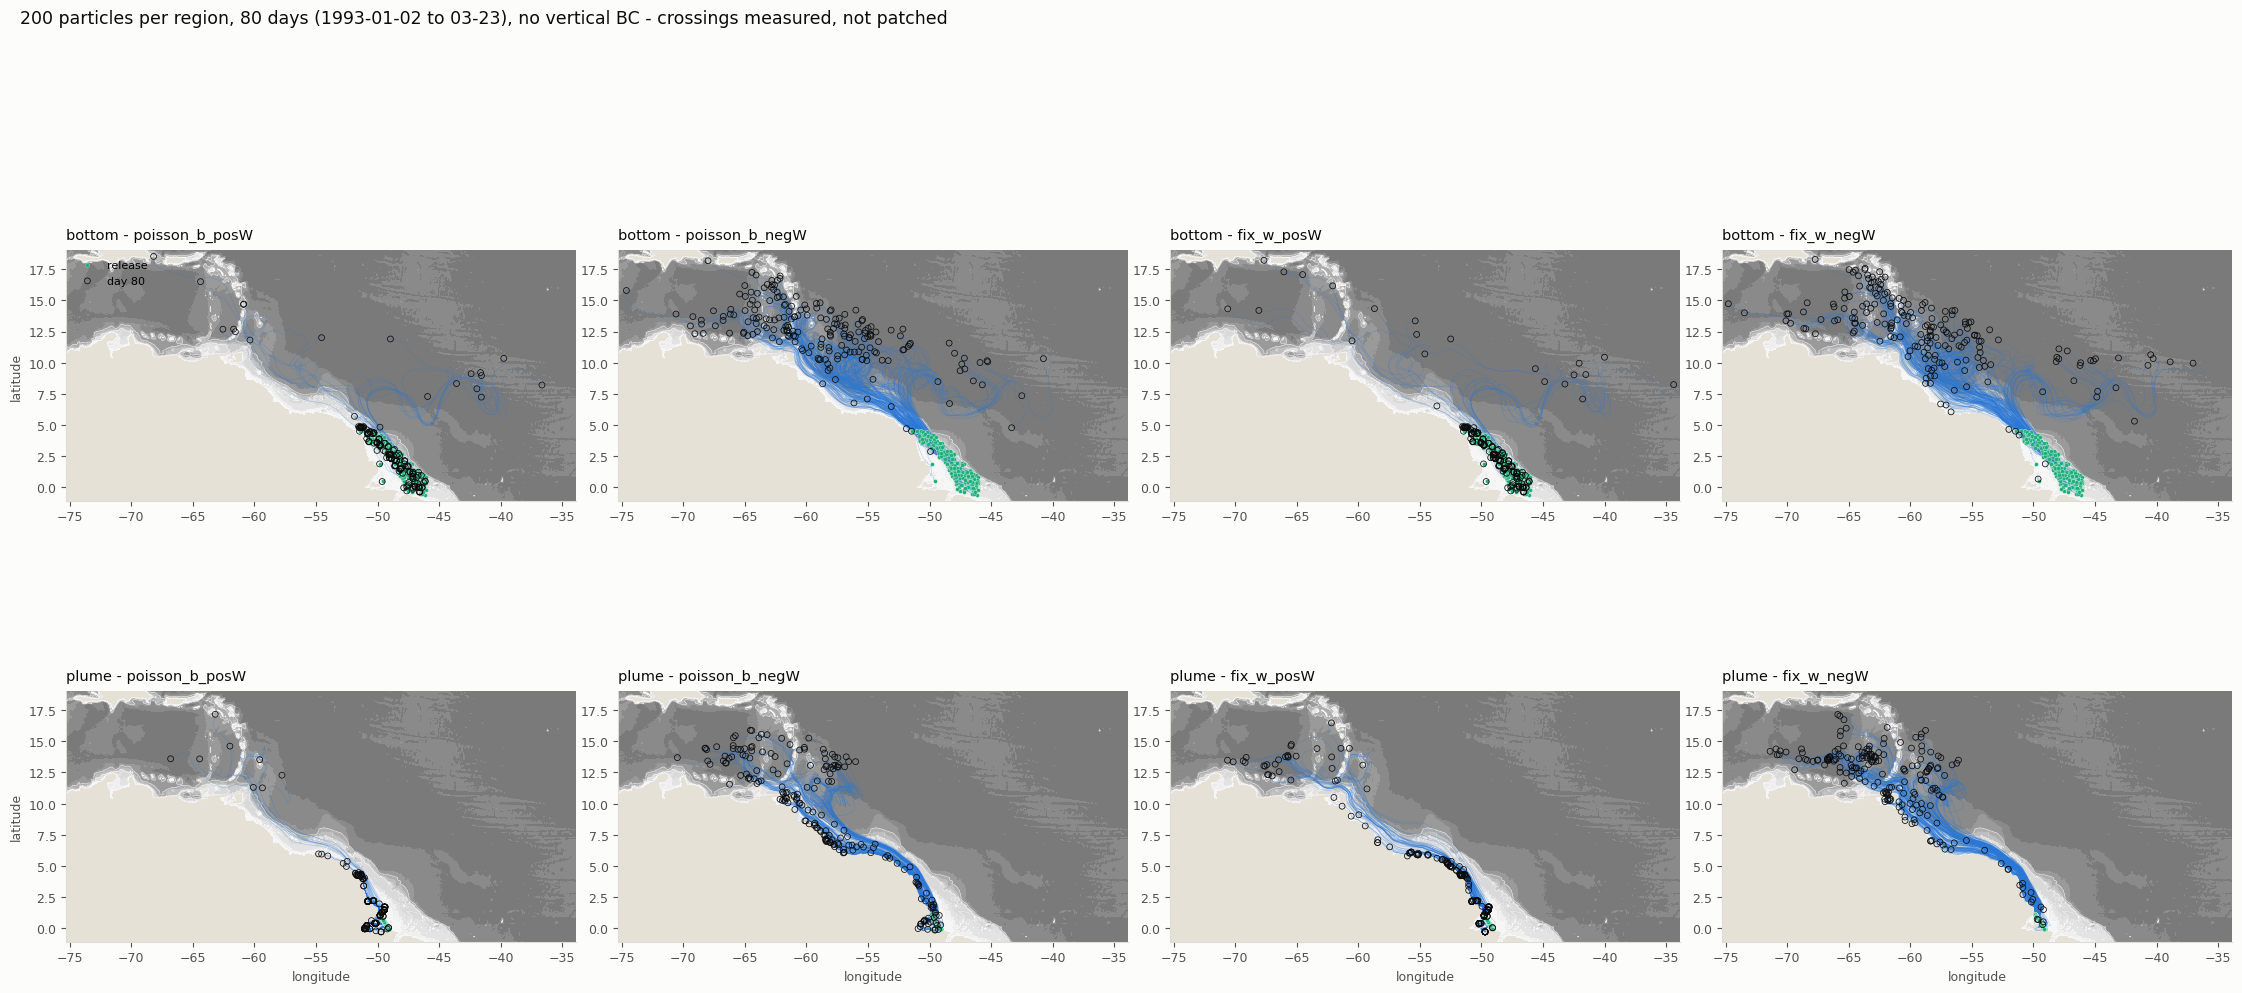

In [7]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

allon = np.concatenate([v["lon"].ravel() for v in TRK.values()])
allat = np.concatenate([v["lat"].ravel() for v in TRK.values()])
x0, x1 = np.nanmin(allon) - 0.5, np.nanmax(allon) + 0.5
y0, y1 = np.nanmin(allat) - 0.5, np.nanmax(allat) + 0.5
m = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
gj, gi = np.where(m); Js, Is = slice(gj.min(), gj.max()+1), slice(gi.min(), gi.max()+1)
LEV = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
bc = ListedColormap(mpl.colormaps["Greys"](np.linspace(0.08, 0.6, len(LEV)-1)))
bc.set_bad("#e6e1d6"); bn = BoundaryNorm(LEV, bc.N)
BATH = np.where(mbathy[Js, Is] > 0, H[Js, Is], np.nan)
cols = list(TRK)

fig, axs = plt.subplots(2, len(cols), figsize=(5.6 * len(cols), 11.2), squeeze=False)
for row, reg in enumerate(REGIONS):
    for col, tag in enumerate(cols):
        ax = axs[row, col]; v = TRK[tag]; s = v["reg"] == row
        ax.set_facecolor("#e6e1d6")
        ax.pcolormesh(lon2d[Js, Is], lat2d[Js, Is], BATH, cmap=bc, norm=bn,
                      shading="auto", zorder=0)
        ax.contour(lon2d[Js, Is], lat2d[Js, Is], np.nan_to_num(BATH),
                   levels=[20, 100, 1000], colors="#ffffff", linewidths=0.45,
                   alpha=0.7, zorder=1)
        ax.plot(v["lon"][s].T, v["lat"][s].T, lw=0.4, color="#2a78d6", alpha=0.35, zorder=2)
        ax.scatter(v["lon"][s, 0], v["lat"][s, 0], s=8, color="#1baf7a",
                   edgecolor="white", linewidth=0.2, zorder=4, label="release")
        nb_ = np.isfinite(v["lat"][s]).sum(axis=1)
        lq = np.where(nb_ > 0, nb_ - 1, 0); rq = np.arange(int(s.sum()))
        ax.scatter(v["lon"][s][rq, lq], v["lat"][s][rq, lq], s=18, facecolor="none",
                   edgecolor="#0b0b0b", linewidth=0.55, zorder=5,
                   label=f"day {run_time_days}")
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
        ax.set_title(f"{reg} - {tag}", loc="left", fontsize=10.5, pad=8)
        if row == 1: ax.set_xlabel("longitude")
        if col == 0: ax.set_ylabel("latitude")
        if row == 0 and col == 0: ax.legend(frameon=False, fontsize=8, loc="upper left")
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.suptitle(f"{n_per_region} particles per region, {run_time_days} days "
             "(1993-01-02 to 03-23), no vertical BC - crossings measured, not patched",
             x=0.005, ha="left", fontsize=12.5, color=INK, y=0.996)
fig.tight_layout(rect=[0, 0, 1, 0.972])
fig.savefig("v4_tracks.png", dpi=160, facecolor=SURF)
plt.show()